In [1]:
import os
import numpy as np
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import heracles
import heracles.dices as dices
from heracles.io import read
from astropy.io import fits
import fitsio

## Comparison

In [2]:
config_path = "scripts/sims_config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
n = config['nsims']
nside = config['nside']
lmax = config['lmax']
lmax_mask = config.get('lmax_mask', lmax)  # Default to lmax if not specified
mode = config['mode']  # "lognormal" or "gaussian"
mask_type = config['mask_type']  # Default to 'Patch' if not specified
binned = False #True
apply_mask = True
nbins = 3

output_path = f"{mode}_dices/"
output_path = "./masked_"+output_path

nlbins = config.get('nlbins', 20)  # Default to 20 if not specified
l = np.arange(lmax+1)
l_mask = np.arange(lmax_mask+1)
ledges = np.logspace(np.log10(10), np.log10(lmax), nlbins + 1)
lgrid = (ledges[1:] + ledges[:-1]) / 2

In [3]:
mask_dr1 = hp.read_map("./dr1/mask.fits")
mask_planck = hp.read_map("./half_sky/mask.fits")

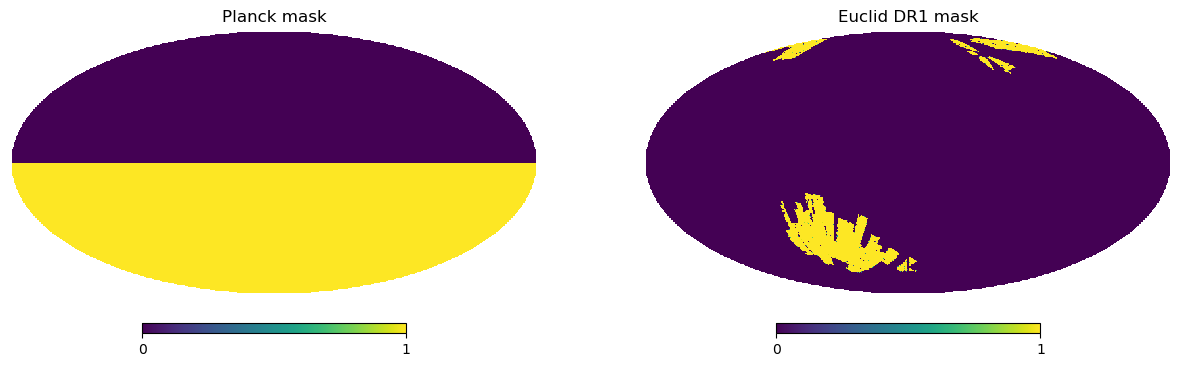

In [4]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 7))

plt.axes(ax2)
hp.mollview(mask_dr1, hold=True, title="Euclid DR1 mask")

plt.axes(ax1)
hp.mollview(mask_planck, hold=True, title="Planck mask")

plt.show()
fig.savefig(f'/home/jaimerzp/Desktop/mixing_mat_plots/masks.pdf', bbox_inches='tight')

In [5]:
def invert_mixing_matrix(M, rtol=1e-5):
    """
    Inversion model for the unmixing E/B modes.
    Args:
        M: Mixing matrix
        Returns:
        inversion_cls: inverted Cl
    """
    inv_M = {}
    for key in M.keys():
        a, b, i, j = key
        _M = M[key].array
        *_, _n, _m = _M.shape
        if a == b == "SHE":
            _inv_m = np.linalg.pinv(
                np.vstack((np.hstack((_M[0], _M[1])), np.hstack((_M[1], _M[0])))),
                rtol=rtol,
            )
            _inv_M_EEEE = _inv_m[:_m, :_n]
            _inv_M_EEBB = _inv_m[_m:, _n:]
            _inv_M_EBEB = np.linalg.pinv(_M[2], rtol=rtol)
            _inv_M = np.array([_inv_M_EEEE, _inv_M_EEBB, _inv_M_EBEB])
        else:
            _inv_M = np.linalg.pinv(_M, rtol=rtol)
        inv_M[key] = heracles.Result(_inv_M, axis=M[key].axis, ell=M[key].ell)
    return inv_M

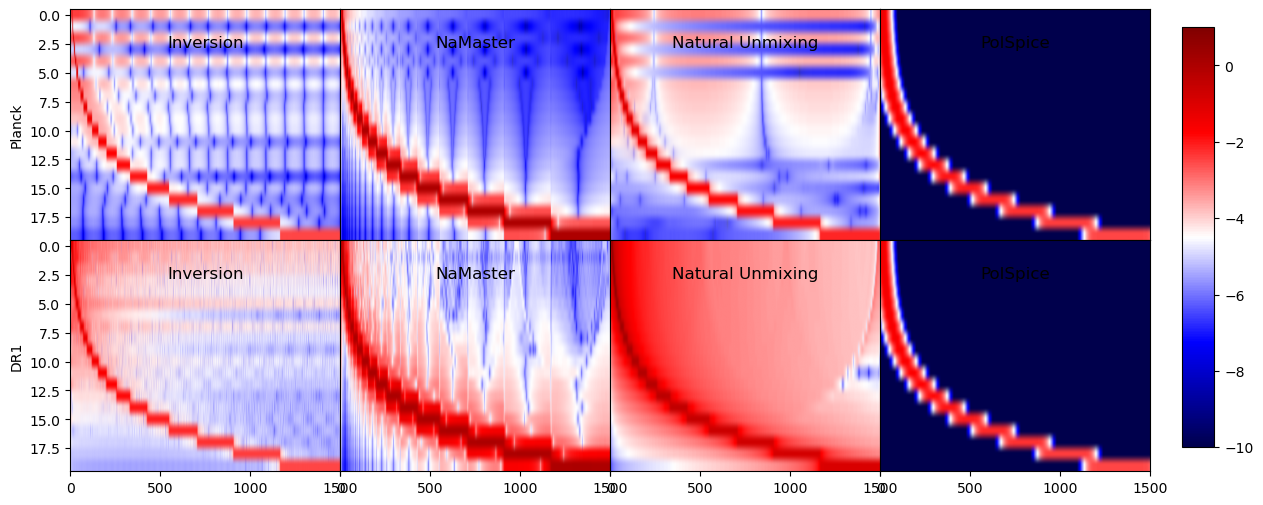

In [6]:
fig, axs = plt.subplots(2, 4, figsize=(16, 6))
plt.subplots_adjust(hspace = 0.0, wspace = 0.0)

#######
## Planck
#######

# Open the FITS file
config_path = "scripts/sims_config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
rtol=1e-2
mixmat = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/half_sky/mixmat_l1max_{lmax}_l2max_{lmax_mask}.fits")
unmixmat = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/half_sky/unmixmat_l1max_{lmax}_l2max_{lmax_mask}.fits")
# bin inverted mixing matrix
inv_mixmat = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/half_sky/inv_mixmat_l1max_{lmax}_l2max_{lmax_mask}.fits")
binv_mixmat = heracles.binned(inv_mixmat, ledges)
# invert binned mixing matrix
bmixmat = heracles.binned(mixmat, ledges)
bmixmatb = {}
for key in bmixmat.keys():
    bmixmatb[key] = heracles.binned(heracles.Result(bmixmat[key].array, axis=bmixmat[key].axis[0]+1, ell=l_mask), ledges)
bmixmatb = heracles.binned(bmixmatb, ledges)
inv_bmixmatb = invert_mixing_matrix(bmixmatb, rtol=rtol)
# Kernels
inv_kernel = binv_mixmat["POS", "POS", 1, 1].array @ mixmat["POS", "POS", 1, 1].array
nmt_kernel = inv_bmixmatb["POS", "POS", 1, 1].array @ bmixmat["POS", "POS", 1, 1].array
pols_kernel = fits.open("/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/half_sky/cls_pols/kernels_pols_1.fits")[0].data[0, :, :].T
pols_kernel = heracles.Result(pols_kernel[:lmax+1, :lmax+1], axis=(0,), ell=l)
pols_kernel = heracles.binned(pols_kernel, ledges).array
nu_kernel = heracles.Result(unmixmat["POS", "POS", 1, 1].array @ mixmat["POS", "POS", 1, 1].array.T, axis=(0,), ell=l)
nu_kernel = heracles.binned(nu_kernel, ledges).array

im0= axs[0, 0].imshow(np.log10(np.abs(inv_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[0, 0].get_xaxis().set_ticks([])
axs[0, 0].set_ylabel("Planck")
axs[0, 0].set_title('Inversion', y=0.8)

axs[0, 1].imshow(np.log10(np.abs(nmt_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[0, 1].get_yaxis().set_ticks([])
axs[0, 1].get_xaxis().set_ticks([])
axs[0, 1].set_title('NaMaster', y=0.8)

axs[0, 2].imshow(np.log10(np.abs(nu_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[0, 2].get_yaxis().set_ticks([])
axs[0, 2].get_xaxis().set_ticks([])
axs[0, 2].set_title('Natural Unmixing', y=0.8)

axs[0, 3].imshow(np.log10(np.abs(pols_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[0, 3].get_yaxis().set_ticks([])
axs[0, 3].get_xaxis().set_ticks([])
axs[0, 3].set_title('PolSpice', y=0.8)

#######
## DR1
#######

# Open the FITS file
config_path = "scripts/sims_config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)
rtol=1e-2
mixmat = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/dr1/mixmat.fits")
unmixmat = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/dr1/unmixmat.fits")
# bin inverted mixing matrix
inv_mixmat = heracles.read(f"/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/dr1/inv_mixmat.fits")
binv_mixmat = heracles.binned(inv_mixmat, ledges)
# invert binned mixing matrix
bmixmat = heracles.binned(mixmat, ledges)
bmixmatb = {}
for key in bmixmat.keys():
    bmixmatb[key] = heracles.binned(heracles.Result(bmixmat[key].array, axis=bmixmat[key].axis[0]+1, ell=l), ledges)
bmixmatb = heracles.binned(bmixmatb, ledges)
inv_bmixmatb = invert_mixing_matrix(bmixmatb, rtol=rtol)
# Kernels
inv_kernel = binv_mixmat["POS", "POS", 1, 1].array @ mixmat["POS", "POS", 1, 1].array
nmt_kernel = inv_bmixmatb["POS", "POS", 1, 1].array @ bmixmat["POS", "POS", 1, 1].array
pols_kernel = fits.open("/home/jaimerzp/Documents/UCL/GLASS_cov_challenge/dr1/cls_pols/kernels_pols_1.fits")[0].data[0, :, :].T
pols_kernel = heracles.Result(pols_kernel[:lmax+1, :lmax+1], axis=(0,), ell=l)
pols_kernel = heracles.binned(pols_kernel, ledges).array
nu_kernel = heracles.Result(unmixmat["POS", "POS", 1, 1].array @ mixmat["POS", "POS", 1, 1].array, axis=(0,), ell=l)
nu_kernel = heracles.binned(nu_kernel, ledges).array

axs[1, 0].imshow(np.log10(np.abs(inv_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[1, 0].set_title('Inversion', y=0.8)
axs[1, 0].set_ylabel("DR1")

axs[1, 1].imshow(np.log10(np.abs(nmt_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[1, 1].get_yaxis().set_ticks([])
axs[1, 1].set_title('NaMaster', y=0.8)

axs[1, 2].imshow(np.log10(np.abs(nu_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[1, 2].get_yaxis().set_ticks([])
axs[1, 2].set_title('Natural Unmixing', y=0.8)

axs[1, 3].imshow(np.log10(np.abs(pols_kernel)), cmap='seismic', aspect='auto', vmin=-10, vmax=1)
axs[1, 3].get_yaxis().set_ticks([])
axs[1, 3].set_title('PolSpice', y=0.8)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.82, 0.15, 0.02, 0.7])
fig.colorbar(im0, cax=cbar_ax)
plt.show()
fig.savefig(f'/home/jaimerzp/Desktop/mixing_mat_plots/kernel_compo_{mask_type}.pdf', bbox_inches='tight')

In [7]:
def get_cls_mean(cls_dict):
    n_keys = list(cls_dict.keys())
    f_keys = list(cls_dict[n_keys[0]].keys())
    cls_mean = {}
    for f_key in f_keys:
        cl = np.mean([cls_dict[i][f_key] for i in n_keys], axis=0)
        cls_mean[f_key] = heracles.Result(cl, axis=cls_dict[n_keys[0]][f_key].axis)
    return cls_mean

In [8]:
theory_cls = heracles.read(f"lognormal_sims/cls_theory.fits")
ls = np.arange(lmax+1)
fl = -np.sqrt((ls+2)*(ls+1)*ls*(ls-1))
fl /= np.clip(ls*(ls+1), 1, None)

_theory_cls = {}
_theory_cls[("POS", "POS", 1, 1)] = heracles.Result(theory_cls["W1xW1"].array[:lmax+1], ell=ls)

c = np.zeros((2, 2, lmax+1))
c[0, 0, :] = theory_cls["W2xW2"].array[:lmax+1] * fl**2
_theory_cls[("SHE", "SHE", 1, 1)] = heracles.Result(c)

c = np.zeros((2, lmax+1))
c[0, :] = theory_cls["W1xW2"].array[:lmax+1] * fl
_theory_cls[("POS", "SHE", 1, 1)] = heracles.Result(c)

_theory_cqs = heracles.binned(_theory_cls, ledges)

In [9]:
#path = "./dummy/"
#cls = {}
#for i in range(1, n+1):
#    print(f"Loading sim {i}", end='\r')
#    cls[i] = heracles.read(path+f"/cls/cls_data_{i}.fits")

#cqs = heracles.binned(cls, ledges)
#_theory_cls = get_cls_mean(cls)
#_theory_cqs = get_cls_mean(cqs)

In [10]:
path = f"./{mask_type}/"
cls = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    cls[i] = heracles.read(path+f"/cls/cls_data_{i}_lmax_{lmax}.fits")

cqs = heracles.binned(cls, ledges)
cls_m = get_cls_mean(cls)
cqs_m = get_cls_mean(cqs)

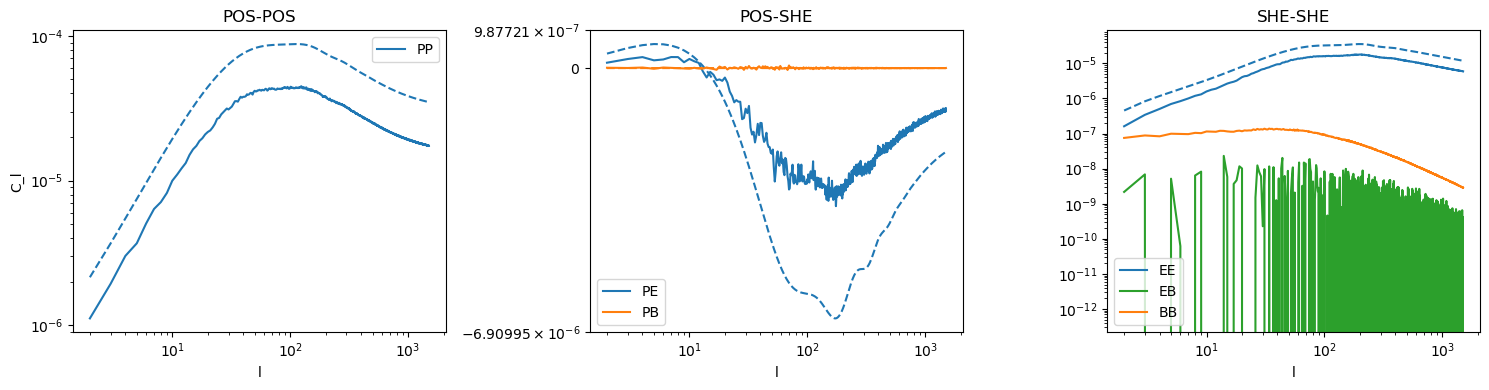

In [11]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
axs[0].plot(l[2:], l[2:]*cls_m[("POS", "POS", 1, 1)].array[2:], color='C0', label='PP')
axs[0].plot(l[2:], l[2:]*_theory_cls[("POS", "POS", 1, 1)].array[2:], color='C0', linestyle='--')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
axs[1].plot(l[2:], l[2:]*cls_m[("POS", "SHE", 1, 1)].array[0][2:], color='C0', label='PE')
axs[1].plot(l[2:], l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[0][2:], color='C0', linestyle='--')
axs[1].plot(l[2:], l[2:]*cls_m[("POS", "SHE", 1, 1)].array[1][2:], color='C1', label='PB')
axs[1].plot(l[2:], l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[1][2:], color='C1', linestyle='--')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_yscale('symlog')
axs[1].set_xlabel("l")

# SHE SHE
axs[2].plot(l[2:], l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', label='EE')
axs[2].plot(l[2:], l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:], color='C0', linestyle='--')
axs[2].plot(l[2:], l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:], color='C2', label='EB')
axs[2].plot(l[2:], l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 1][2:], color='C2', linestyle='--')
axs[2].plot(l[2:], l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', label='BB')
axs[2].plot(l[2:], l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:], color='C1', linestyle='--')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
axs[2].set_yscale('log')
#axs[2].set_yscale('symlog', linthresh=5e-10)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

In [12]:
mask = hp.read_map(f"{mask_type}/mask.fits")
fsky=np.sum(mask)/len(mask)

/tmp/ipykernel_57909/373199446.py:14: RuntimeWarning: divide by zero encountered in divide
  axs[1].plot(l[2:], (l[2:]*cls_m[("POS", "SHE", 1, 1)].array[1][2:]-fsky*l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[1][2:])/(fsky*l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[1][2:]), color='C1', label='PB')
/tmp/ipykernel_57909/373199446.py:22: RuntimeWarning: divide by zero encountered in divide
  axs[2].plot(l[2:], (l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:]-fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 1][2:])/(fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 1][2:]), color='C2', label='EB')
/tmp/ipykernel_57909/373199446.py:23: RuntimeWarning: divide by zero encountered in divide
  axs[2].plot(l[2:], (l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:]-fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:])/(fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:]), color='C1', label='BB')


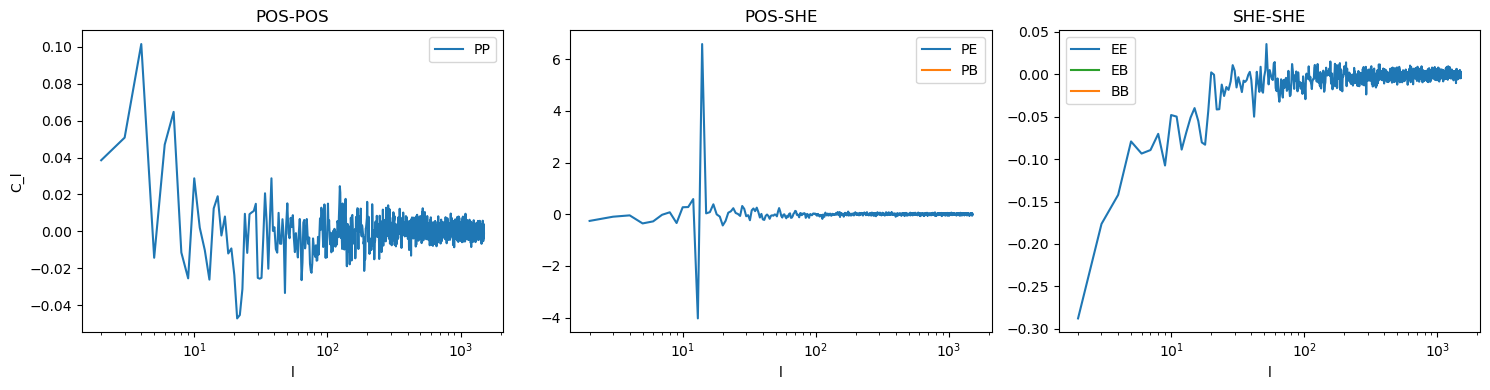

In [13]:
# Create a figure with 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

# POS POS
axs[0].plot(l[2:], (l[2:]*cls_m[("POS", "POS", 1, 1)].array[2:]-fsky*l[2:]*_theory_cls[("POS", "POS", 1, 1)].array[2:])/(fsky*l[2:]*_theory_cls[("POS", "POS", 1, 1)].array[2:]), color='C0', label='PP')
axs[0].legend()
axs[0].set_title("POS-POS")
axs[0].set_xscale('log')
axs[0].set_xlabel("l")
axs[0].set_ylabel("C_l")

# POS SHE
axs[1].plot(l[2:], (l[2:]*cls_m[("POS", "SHE", 1, 1)].array[0][2:]-fsky*l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[0][2:])/(fsky*l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[0][2:]), color='C0', label='PE')
axs[1].plot(l[2:], (l[2:]*cls_m[("POS", "SHE", 1, 1)].array[1][2:]-fsky*l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[1][2:])/(fsky*l[2:]*_theory_cls[("POS", "SHE", 1, 1)].array[1][2:]), color='C1', label='PB')
axs[1].legend()
axs[1].set_title("POS-SHE")
axs[1].set_xscale('log')
axs[1].set_xlabel("l")

# SHE SHE
axs[2].plot(l[2:], (l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[0, 0][2:]-fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:])/(fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 0][2:]), color='C0', label='EE')
axs[2].plot(l[2:], (l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[0, 1][2:]-fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 1][2:])/(fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[0, 1][2:]), color='C2', label='EB')
axs[2].plot(l[2:], (l[2:]*cls_m[("SHE", "SHE", 1, 1)].array[1, 1][2:]-fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:])/(fsky*l[2:]*_theory_cls[("SHE", "SHE", 1, 1)].array[1, 1][2:]), color='C1', label='BB')
axs[2].legend()
axs[2].set_title("SHE-SHE")
axs[2].set_xscale('log')
#axs[2].set_yscale('symlog', linthresh=5e-10)
axs[2].set_xlabel("l")

# Adjust layout
plt.tight_layout()
plt.show()

In [14]:
## Planck
path = "./half_sky/"
planck_inv_cls = {}
planck_nu_cls = {}
planck_pols_cls = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    planck_inv_cls[i] = heracles.read(path+f"/cls_inv/cls_data_inv_{i}_l1max_{lmax}_l2max_{lmax_mask}.fits")
    planck_nu_cls[i] = heracles.read(path+f"/cls_nu/cls_data_nu_{i}_l1max_{lmax}_l2max_{lmax_mask}.fits")
    planck_pols_cls[i] = heracles.read(path+f"/cls_pols/cls_data_pols_{i}.fits")

planck_nmt_cqs = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    planck_nmt_cqs[i] = heracles.read(path+f"/cls_nmt/cqs_data_nmt_np_{i}.fits")
planck_inv_cqs = heracles.binned(planck_inv_cls, ledges)
planck_nu_cqs = heracles.binned(planck_nu_cls, ledges)
planck_pols_cqs = heracles.binned(planck_pols_cls, ledges)

## DR1
path = "./dr1/"
dr1_inv_cls = {}
dr1_nu_cls = {}
dr1_pols_cls = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    dr1_inv_cls[i] = heracles.read(path+f"/cls_inv/cls_data_inv_{i}.fits")
    dr1_nu_cls[i] = heracles.read(path+f"/cls_nu/cls_data_nu_{i}.fits")
    dr1_pols_cls[i] = heracles.read(path+f"/cls_pols/cls_data_pols_{i}.fits")

dr1_nmt_cqs = {}
for i in range(1, n+1):
    print(f"Loading sim {i}", end='\r')
    dr1_nmt_cqs[i] = heracles.read(path+f"/cls_nmt/cqs_data_nmt_np_{i}.fits")
dr1_inv_cqs = heracles.binned(dr1_inv_cls, ledges)
dr1_nu_cqs = heracles.binned(dr1_nu_cls, ledges)
dr1_pols_cqs = heracles.binned(dr1_pols_cls, ledges)

In [15]:
## Planck means
planck_inv_cls_m = get_cls_mean(planck_inv_cls)
planck_nu_cls_m = get_cls_mean(planck_nu_cls)
planck_pols_cls_m = get_cls_mean(planck_pols_cls)

planck_inv_cqs_m = get_cls_mean(planck_inv_cqs)
planck_nu_cqs_m = get_cls_mean(planck_nu_cqs)
planck_pols_cqs_m = get_cls_mean(planck_pols_cqs)
planck_nmt_cqs_m = get_cls_mean(planck_nmt_cqs)

## DR1 means
dr1_inv_cls_m = get_cls_mean(dr1_inv_cls)
dr1_nu_cls_m = get_cls_mean(dr1_nu_cls)
dr1_pols_cls_m = get_cls_mean(dr1_pols_cls)

dr1_inv_cqs_m = get_cls_mean(dr1_inv_cqs)
dr1_nu_cqs_m = get_cls_mean(dr1_nu_cqs)
dr1_pols_cqs_m = get_cls_mean(dr1_pols_cqs)
dr1_nmt_cqs_m = get_cls_mean(dr1_nmt_cqs)

In [16]:
## Planck covariances
planck_ensemble_cov = heracles.read(f"half_sky/covs/cov_cls_l1max_{lmax}_l2max_{lmax_mask}.fits")
planck_ensemble_covqq = heracles.read(f"half_sky/covs/cov_cqs_l1max_{lmax}_l2max_{lmax_mask}.fits")

planck_inv_ensemble_cov = heracles.read(f"half_sky/covs/cov_inv_cls_l1max_{lmax}_l2max_{lmax_mask}.fits")
planck_nu_ensemble_cov = heracles.read(f"half_sky/covs/cov_nu_cls_l1max_{lmax}_l2max_{lmax_mask}.fits")
planck_pols_ensemble_cov = heracles.read(f"half_sky/covs/cov_pols_cls_l1max_{lmax}_l2max_{lmax_mask}.fits")

planck_inv_ensemble_covqq = heracles.read(f"half_sky/covs/cov_inv_cqs_l1max_{lmax}_l2max_{lmax_mask}.fits")
planck_nu_ensemble_covqq = heracles.read(f"half_sky/covs/cov_nu_cqs_l1max_{lmax}_l2max_{lmax_mask}.fits")
planck_nmt_ensemble_covqq = heracles.read(f"half_sky/covs/cov_nmt_cqs_l1max_{lmax}_l2max_{lmax_mask}.fits")
planck_pols_ensemble_covqq = heracles.read(f"half_sky/covs/cov_pols_cqs_l1max_{lmax}_l2max_{lmax_mask}.fits")

planck_flat_ensemble_cov = dices.flatten(planck_ensemble_covqq)
planck_flat_inv_ensemble_cov = dices.flatten(planck_inv_ensemble_covqq)
planck_flat_nu_ensemble_cov = dices.flatten(planck_nu_ensemble_covqq)
planck_flat_pols_ensemble_cov = dices.flatten(planck_pols_ensemble_covqq)
planck_flat_nmt_ensemble_cov = dices.flatten(planck_nmt_ensemble_covqq)

planck_flat_ensemble_corr = planck_flat_ensemble_cov / np.sqrt(
    np.diag(planck_flat_ensemble_cov)[:, None] * np.diag(planck_flat_ensemble_cov)[None, :]
)
planck_flat_inv_ensemble_corr = planck_flat_inv_ensemble_cov / np.sqrt(
    np.diag(planck_flat_inv_ensemble_cov)[:, None] * np.diag(planck_flat_inv_ensemble_cov)[None, :]
)
planck_flat_nu_ensemble_corr = planck_flat_nu_ensemble_cov / np.sqrt(
    np.diag(planck_flat_nu_ensemble_cov)[:, None] * np.diag(planck_flat_nu_ensemble_cov)[None, :]
)
planck_flat_pols_ensemble_corr = planck_flat_pols_ensemble_cov / np.sqrt(
    np.diag(planck_flat_pols_ensemble_cov)[:, None] * np.diag(planck_flat_pols_ensemble_cov)[None, :]
)
planck_flat_nmt_ensemble_corr = planck_flat_nmt_ensemble_cov / np.sqrt(
    np.diag(planck_flat_nmt_ensemble_cov)[:, None] * np.diag(planck_flat_nmt_ensemble_cov)[None, :]
)

## DR1 covariances
dr1_ensemble_cov = heracles.read("dr1/covs/cov_cls.fits")
dr1_ensemble_covqq = heracles.read("dr1/covs/cov_cqs.fits")

dr1_inv_ensemble_cov = heracles.read("dr1/covs/cov_inv_cls.fits")
dr1_nu_ensemble_cov = heracles.read("dr1/covs/cov_nu_cls.fits")
dr1_pols_ensemble_cov = heracles.read("dr1/covs/cov_pols_cls.fits")

dr1_inv_ensemble_covqq = heracles.read("dr1/covs/cov_inv_cqs.fits")
dr1_nu_ensemble_covqq = heracles.read("dr1/covs/cov_nu_cqs.fits")
dr1_nmt_ensemble_covqq = heracles.read("dr1/covs/cov_nmt_cqs.fits")
dr1_pols_ensemble_covqq = heracles.read("dr1/covs/cov_pols_cqs.fits")

dr1_flat_ensemble_cov = dices.flatten(dr1_ensemble_covqq)
dr1_flat_inv_ensemble_cov = dices.flatten(dr1_inv_ensemble_covqq)
dr1_flat_nu_ensemble_cov = dices.flatten(dr1_nu_ensemble_covqq)
dr1_flat_pols_ensemble_cov = dices.flatten(dr1_pols_ensemble_covqq)
dr1_flat_nmt_ensemble_cov = dices.flatten(dr1_nmt_ensemble_covqq)

dr1_flat_ensemble_corr = dr1_flat_ensemble_cov / np.sqrt(
    np.diag(dr1_flat_ensemble_cov)[:, None] * np.diag(dr1_flat_ensemble_cov)[None, :]
)
dr1_flat_inv_ensemble_corr = dr1_flat_inv_ensemble_cov / np.sqrt(
    np.diag(dr1_flat_inv_ensemble_cov)[:, None] * np.diag(dr1_flat_inv_ensemble_cov)[None, :]
)
dr1_flat_nu_ensemble_corr = dr1_flat_nu_ensemble_cov / np.sqrt(
    np.diag(dr1_flat_nu_ensemble_cov)[:, None] * np.diag(dr1_flat_nu_ensemble_cov)[None, :]
)
dr1_flat_pols_ensemble_corr = dr1_flat_pols_ensemble_cov / np.sqrt(
    np.diag(dr1_flat_pols_ensemble_cov)[:, None] * np.diag(dr1_flat_pols_ensemble_cov)[None, :]
)
dr1_flat_nmt_ensemble_corr = dr1_flat_nmt_ensemble_cov / np.sqrt(
    np.diag(dr1_flat_nmt_ensemble_cov)[:, None] * np.diag(dr1_flat_nmt_ensemble_cov)[None, :]
)

In [17]:
def combine_matrices(A, B):
    """
    Combines two square matrices:
    - Lower triangle (including diagonal) from A
    - Upper triangle from B
    """
    # Make sure A and B are numpy arrays
    A = np.array(A)
    B = np.array(B)

    # Create an empty matrix
    C = np.zeros_like(A)

    # Use masks for lower and upper triangles
    lower_mask = np.tri(A.shape[0], dtype=bool)  # i >= j
    upper_mask = ~lower_mask                     # i < j

    # Assign values
    C[lower_mask] = A[lower_mask]
    C[upper_mask] = B[upper_mask]

    return C

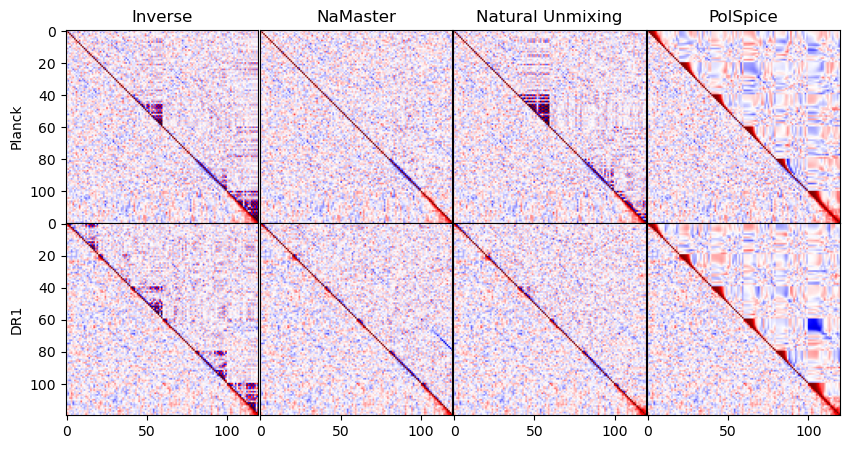

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
plt.subplots_adjust(hspace = 0.0, wspace = 0.0)

# Flattened Inverse Covariance
comb_corr = combine_matrices(planck_flat_ensemble_corr, planck_flat_inv_ensemble_corr)
axes[0, 0].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[0, 0].set_ylabel("Planck")
axes[0, 0].set_title("Inverse")
axes[0, 0].get_xaxis().set_ticks([])
# Flattened NaMaster covariance
comb_corr = combine_matrices(planck_flat_ensemble_corr, planck_flat_nmt_ensemble_corr)
axes[0, 1].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[0, 1].set_title("NaMaster")
axes[0, 1].get_yaxis().set_ticks([])
axes[0, 1].get_xaxis().set_ticks([])
# Flattened Nautural Unmixing Covariance
comb_corr = combine_matrices(planck_flat_ensemble_corr, planck_flat_nu_ensemble_corr)
axes[0, 2].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[0, 2].set_title("Natural Unmixing")
axes[0, 2].get_yaxis().set_ticks([])
axes[0, 2].get_xaxis().set_ticks([])
# Flattened PolSpice Covariance
comb_corr = combine_matrices(planck_flat_ensemble_corr, planck_flat_pols_ensemble_corr)
axes[0, 3].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[0, 3].set_title("PolSpice")
axes[0, 3].get_yaxis().set_ticks([])
axes[0, 3].get_xaxis().set_ticks([])

# Flattened Inverse Covariance
comb_corr = combine_matrices(dr1_flat_ensemble_corr, dr1_flat_inv_ensemble_corr)
axes[1, 0].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[1, 0].set_ylabel("DR1")
# Flattened NaMaster covariance
comb_corr = combine_matrices(dr1_flat_ensemble_corr, dr1_flat_nmt_ensemble_corr)
axes[1, 1].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[1, 1].get_yaxis().set_ticks([])
# Flattened Nautural Unmixing Covariance
comb_corr = combine_matrices(dr1_flat_ensemble_corr, dr1_flat_nu_ensemble_corr)
axes[1, 2].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[1, 2].get_yaxis().set_ticks([])
# Flattened PolSpice Covariance
comb_corr = combine_matrices(dr1_flat_ensemble_corr, dr1_flat_pols_ensemble_corr)
axes[1, 3].imshow(comb_corr, cmap="seismic", vmin=-1, vmax=1)
axes[1, 3].get_yaxis().set_ticks([])

#plt.tight_layout()
plt.show()
fig.savefig(f'/home/jaimerzp/Desktop/mixing_mat_plots/corr_comp.pdf', bbox_inches='tight')

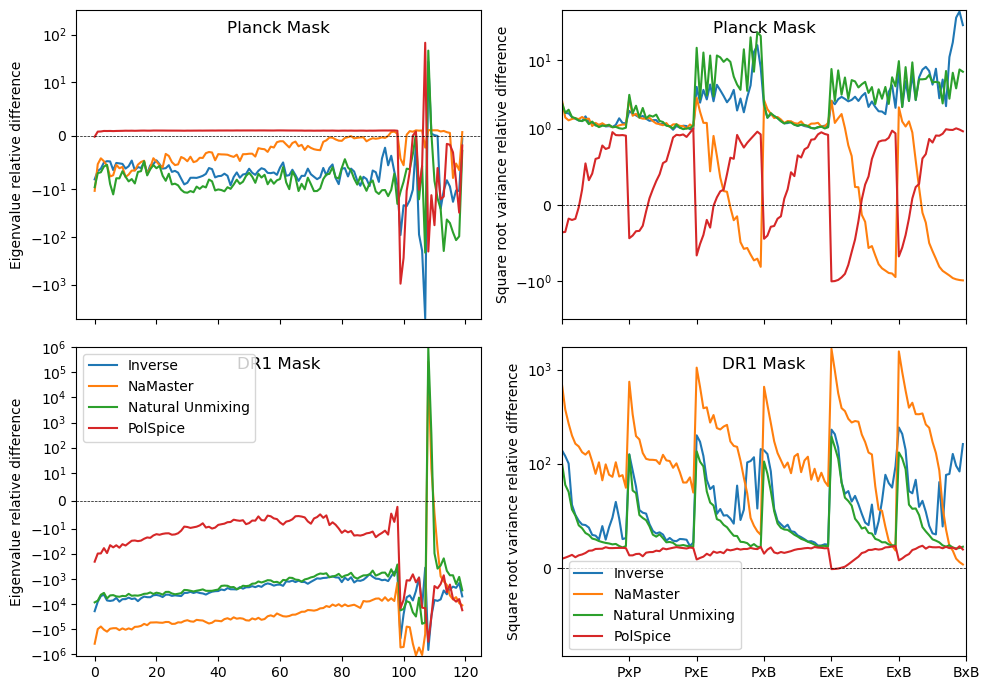

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.subplots_adjust(hspace = 0.1)

# First row: Eigenvalue relative difference
eig_ens_sorted = np.sort(np.linalg.eigvalsh(planck_flat_ensemble_cov))[::-1]
eig_inv_ens_sorted = np.sort(np.linalg.eigvalsh(planck_flat_inv_ensemble_cov))[::-1]
eig_nmt_ens_sorted = np.sort(np.linalg.eigvalsh(planck_flat_nmt_ensemble_cov))[::-1]
eig_nu_ens_sorted = np.sort(np.linalg.eigvalsh(planck_flat_nu_ensemble_cov))[::-1]
eig_pols_ens_sorted = np.sort(np.linalg.eigvalsh(planck_flat_pols_ensemble_cov))[::-1]

axes[0, 0].plot(1 - eig_inv_ens_sorted/eig_ens_sorted, label='Inverse')
axes[0, 0].plot(1 - eig_nmt_ens_sorted/eig_ens_sorted, label='NaMaster')
axes[0, 0].plot(1 - eig_nu_ens_sorted/eig_ens_sorted, label='Natural Unmixing')
axes[0, 0].plot(1 - eig_pols_ens_sorted/eig_ens_sorted, label='PolSpice')

axes[0, 0].set_xticklabels([])
axes[0, 0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[0, 0].set_yscale('symlog', linthresh=1e1)
axes[0, 0].set_ylabel('Eigenvalue relative difference')
axes[0, 0].set_title('Planck Mask', y=0.9)

eig_ens_sorted = np.sort(np.linalg.eigvalsh(dr1_flat_ensemble_cov))[::-1]
eig_inv_ens_sorted = np.sort(np.linalg.eigvalsh(dr1_flat_inv_ensemble_cov))[::-1]
eig_nmt_ens_sorted = np.sort(np.linalg.eigvalsh(dr1_flat_nmt_ensemble_cov))[::-1]
eig_nu_ens_sorted = np.sort(np.linalg.eigvalsh(dr1_flat_nu_ensemble_cov))[::-1]
eig_pols_ens_sorted = np.sort(np.linalg.eigvalsh(dr1_flat_pols_ensemble_cov))[::-1]

axes[1, 0].plot(1 - eig_inv_ens_sorted/eig_ens_sorted, label='Inverse')
axes[1, 0].plot(1 - eig_nmt_ens_sorted/eig_ens_sorted, label='NaMaster')
axes[1, 0].plot(1 - eig_nu_ens_sorted/eig_ens_sorted, label='Natural Unmixing')
axes[1, 0].plot(1 - eig_pols_ens_sorted/eig_ens_sorted, label='PolSpice')

axes[1, 0].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[1, 0].set_yscale('symlog', linthresh=1e1)
axes[1, 0].set_ylabel('Eigenvalue relative difference')
axes[1, 0].set_title('DR1 Mask', y=0.9)
axes[1, 0].legend()

# Second row: Diagonal of Covariance Matrices
ens_err = np.sqrt(np.diag(planck_flat_ensemble_cov))
inv_ens_err = np.sqrt(np.diag(planck_flat_inv_ensemble_cov))
nmt_ens_err = np.sqrt(np.diag(planck_flat_nmt_ensemble_cov))
nu_ens_err = np.sqrt(np.diag(planck_flat_nu_ensemble_cov))
pols_ens_err = np.sqrt(np.diag(planck_flat_pols_ensemble_cov))

axes[0, 1].plot((inv_ens_err-ens_err)/ens_err, label='Inverse')
axes[0, 1].plot((nmt_ens_err-ens_err)/ens_err, label='NaMaster')
axes[0, 1].plot((nu_ens_err-ens_err)/ens_err, label='Natural Unmixing')
axes[0, 1].plot((pols_ens_err-ens_err)/ens_err, label='PolSpice')

axes[0, 1].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[0, 1].set_ylabel('Square root variance relative difference')
axes[0, 1].set_xlim(0, 120)
axes[0, 1].set_yscale('symlog', linthresh=1e0)
axes[0, 1].set_xticklabels([])
axes[0, 1].set_title('Planck Mask', y=0.9)

ens_err = np.sqrt(np.diag(dr1_flat_ensemble_cov))
inv_ens_err = np.sqrt(np.diag(dr1_flat_inv_ensemble_cov))
nmt_ens_err = np.sqrt(np.diag(dr1_flat_nmt_ensemble_cov))
nu_ens_err = np.sqrt(np.diag(dr1_flat_nu_ensemble_cov))
pols_ens_err = np.sqrt(np.diag(dr1_flat_pols_ensemble_cov))

axes[1, 1].plot((inv_ens_err-ens_err)/ens_err, label='Inverse')
axes[1, 1].plot((nmt_ens_err-ens_err)/ens_err, label='NaMaster')
axes[1, 1].plot((nu_ens_err-ens_err)/ens_err, label='Natural Unmixing')
axes[1, 1].plot((pols_ens_err-ens_err)/ens_err, label='PolSpice')

axes[1, 1].axhline(0, color='k', linestyle='--', linewidth=0.5)
axes[1, 1].set_ylabel('Square root variance relative difference')
axes[1, 1].set_xlim(0, 120)
axes[1, 1].set_yscale('symlog', linthresh=1e2)
axes[1, 1].set_xticks(np.arange(20, 121, 20))
axes[1, 1].set_xticklabels(["PxP", "PxE", "PxB", "ExE", "ExB", "BxB"])
axes[1, 1].set_title('DR1 Mask', y=0.9)
axes[1, 1].legend()

plt.tight_layout()
plt.show()
fig.savefig(f'/home/jaimerzp/Desktop/mixing_mat_plots/cov_comp.pdf', bbox_inches='tight')

<>:106: SyntaxWarning: invalid escape sequence '\e'
<>:111: SyntaxWarning: invalid escape sequence '\e'
<>:469: SyntaxWarning: invalid escape sequence '\e'
<>:474: SyntaxWarning: invalid escape sequence '\e'
<>:106: SyntaxWarning: invalid escape sequence '\e'
<>:111: SyntaxWarning: invalid escape sequence '\e'
<>:469: SyntaxWarning: invalid escape sequence '\e'
<>:474: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_57909/1096236972.py:106: SyntaxWarning: invalid escape sequence '\e'
  ax[0, 0].set_ylabel("$\ell C_\ell$")
/tmp/ipykernel_57909/1096236972.py:111: SyntaxWarning: invalid escape sequence '\e'
  ax[1, 0].set_xlabel("$\ell$")
/tmp/ipykernel_57909/1096236972.py:469: SyntaxWarning: invalid escape sequence '\e'
  ax[2, 0].set_ylabel("$\ell C_\ell$")
/tmp/ipykernel_57909/1096236972.py:474: SyntaxWarning: invalid escape sequence '\e'
  ax[3, 0].set_xlabel("$\ell$")


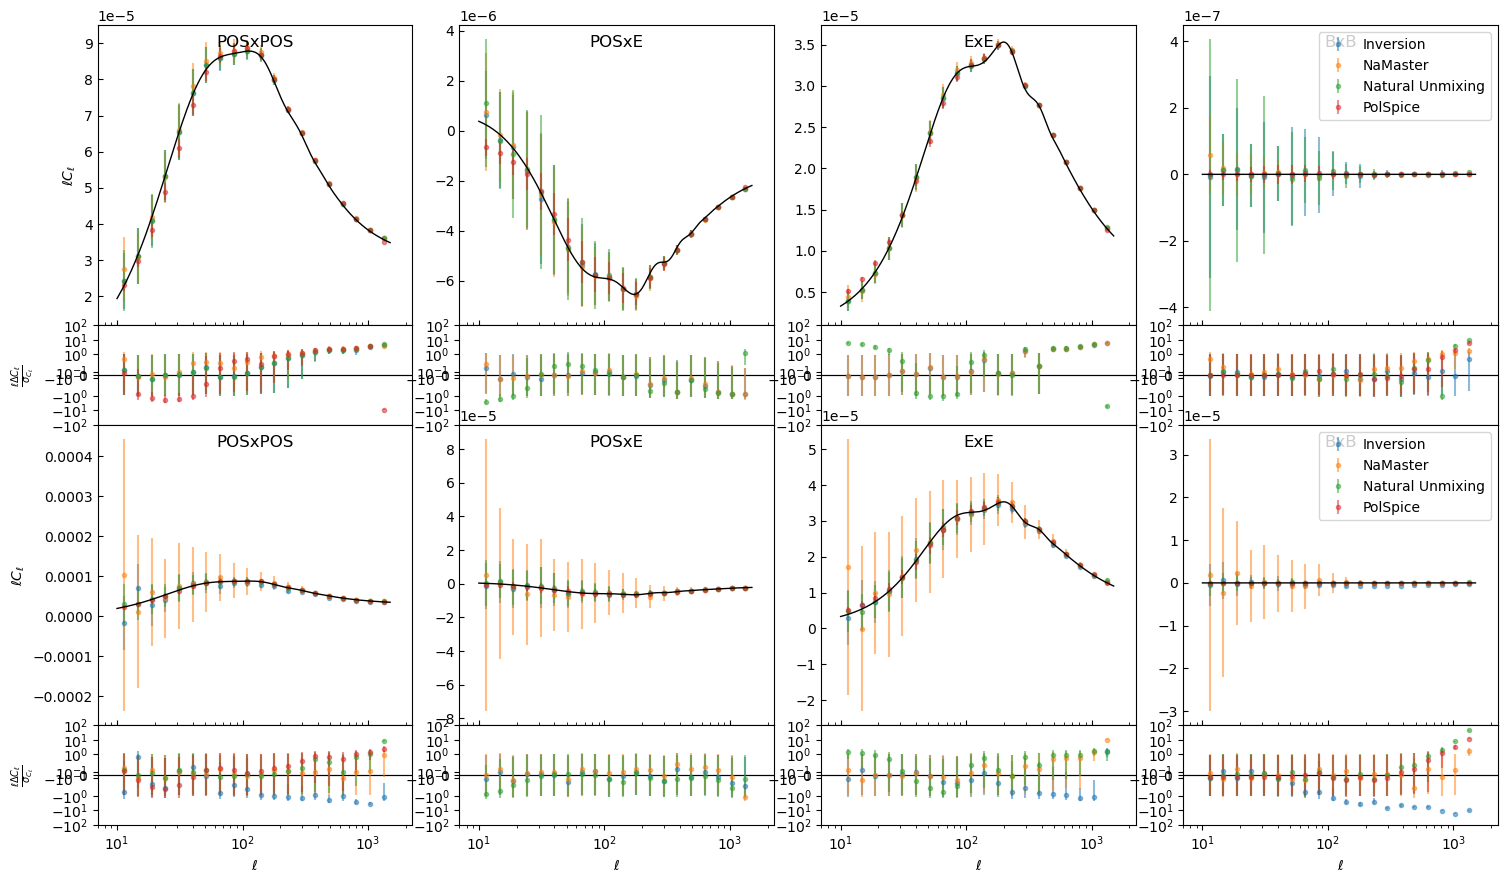

In [26]:
fig, ax = plt.subplots(4, 4, figsize=(14, 8), 
                       gridspec_kw={"height_ratios": [3, 1, 3, 1]})
fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.15, hspace=0.0)

#########
## Planck
#########

inv_ensemble_covqq = planck_inv_ensemble_covqq
nmt_ensemble_covqq = planck_nmt_ensemble_covqq
nu_ensemble_covqq = planck_nu_ensemble_covqq
pols_ensemble_covqq = planck_pols_ensemble_covqq

inv_cqs_m = planck_inv_cqs_m
nmt_cqs_m = planck_nmt_cqs_m
nu_cqs_m = planck_nu_cqs_m
pols_cqs_m = planck_pols_cqs_m

# POS
key = ("POS", "POS", 1, 1)
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key]
nmt_cov = nmt_ensemble_covqq[cov_key]
nu_cov = nu_ensemble_covqq[cov_key]
pp_cov = pols_ensemble_covqq[cov_key]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key]
nmt_c = nmt_cqs_m[key]
nu_c = nu_cqs_m[key]
pp_c = pols_cqs_m[key]
t = _theory_cls[key]
t_itp = np.interp(lgrid, ls, t)


ax[0, 0].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 0].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[0, 0].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 0].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
    )
ax[0, 0].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 0].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (nmt_c - t_itp) / nmt_err,
    yerr=np.abs(nmt_err / nmt_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C3", 
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 0].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_title("POSxPOS", y=0.9)
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(7, lmax * 1.5)
ax[0, 0].set_ylabel("$\ell C_\ell$")
ax[1, 0].set_yscale("symlog", linthresh=5e-1)
ax[1, 0].set_ylim(-100, 100)
ax[1, 0].set_xscale("log")
ax[1, 0].set_xlim(7, lmax * 1.5)
ax[1, 0].set_xlabel("$\ell$")
ax[1, 0].set_ylabel(r"$\frac{\ell \Delta C_\ell}{\sigma_{C_\ell}}$")

# POS-E
key = ("POS", "SHE", 1, 1)
cov_key = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 0, :, :]
nmt_cov = nmt_ensemble_covqq[cov_key][0, 0, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 0, :, :]
pp_cov = pols_ensemble_covqq[cov_key][0, 0, :, :]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key][0, :]
nmt_c = nmt_cqs_m[key][0, :]
nu_c = nu_cqs_m[key][0, :]
pp_c = pols_cqs_m[key][0, :]
t = _theory_cls[key][0, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 1].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 1].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[0, 1].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 1].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 1].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[0, 1].tick_params(axis="both", which="both", direction="in")
ax[1, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[0, 1].set_title("POSxE", y=0.9)
ax[0, 1].set_xscale("log")
ax[0, 1].set_xlim(7, lmax * 1.5)
ax[1, 1].set_yscale("symlog", linthresh=5e-1)
ax[1, 1].set_ylim(-100, 100)
ax[1, 1].set_xscale("log")
ax[1, 1].set_xlim(7, lmax * 1.5)
ax[1, 1].set_xlabel(r"$\ell$")

# EE
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
nmt_cov = nmt_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
pp_cov = pols_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key][0, 0, :]
nmt_c = nmt_cqs_m[key][0, 0, :]
nu_c = nu_cqs_m[key][0, 0, :]
pp_c = pols_cqs_m[key][0, 0, :]
t = _theory_cls[key][0, 0, :]
t_itp = np.interp(lgrid, ls, t)

ax[0, 2].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 2].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[0, 2].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 2].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 2].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[0, 2].set_title("ExE", y=0.9)
ax[1, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[0, 2].tick_params(axis="both", which="both", direction="in")
ax[0, 2].set_xscale("log")
ax[0, 2].set_xlim(7, lmax * 1.5)
ax[1, 2].set_yscale("symlog", linthresh=5e-1)
ax[1, 2].set_ylim(-100, 100)
ax[1, 2].set_xscale("log")
ax[1, 2].set_xlim(7, lmax * 1.5)
ax[1, 2].set_xlabel(r"$\ell$")

# BB
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
nmt_cov = nmt_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
nu_cov = nu_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
pp_cov = pols_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key][1, 1, :]
nmt_c = nmt_cqs_m[key][1, 1, :]
nu_c = nu_cqs_m[key][1, 1, :]
pp_c = pols_cqs_m[key][1, 1, :]
t = _theory_cls[key][1, 1, :]
t_itp = np.interp(lgrid, ls, t)


ax[0, 3].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[0, 3].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[0, 3].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[0, 3].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
    )
ax[0, 3].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[1, 3].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[1, 3].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 3].errorbar(
    lgrid,
    (nmt_c - t_itp) / nmt_err,
    yerr=np.abs(nmt_err / nmt_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 3].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[1, 3].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C3", 
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)

ax[0, 3].legend()
ax[0, 3].tick_params(axis="both", which="both", direction="in")
ax[1, 3].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[0, 3].set_title("BxB", y=0.9)
ax[0, 3].set_xscale("log")
ax[0, 3].set_xlim(7, lmax * 1.5)
ax[1, 3].set_yscale("symlog", linthresh=5e-1)
ax[1, 3].set_ylim(-100, 100)
ax[1, 3].set_xscale("log")
ax[1, 3].set_xlim(7, lmax * 1.5)
ax[1, 3].set_xlabel(r"$\ell$")

#######
## DR1
#######

inv_ensemble_covqq = dr1_inv_ensemble_covqq
nmt_ensemble_covqq = dr1_nmt_ensemble_covqq
nu_ensemble_covqq = dr1_nu_ensemble_covqq
pols_ensemble_covqq = dr1_pols_ensemble_covqq

inv_cqs_m = dr1_inv_cqs_m
nmt_cqs_m = dr1_nmt_cqs_m
nu_cqs_m = dr1_nu_cqs_m
pols_cqs_m = dr1_pols_cqs_m

# POS
key = ("POS", "POS", 1, 1)
cov_key = ("POS", "POS", "POS", "POS", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key]
nmt_cov = nmt_ensemble_covqq[cov_key]
nu_cov = nu_ensemble_covqq[cov_key]
pp_cov = pols_ensemble_covqq[cov_key]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key]
nmt_c = nmt_cqs_m[key]
nu_c = nu_cqs_m[key]
pp_c = pols_cqs_m[key]
t = _theory_cls[key]
t_itp = np.interp(lgrid, ls, t)


ax[2, 0].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[2, 0].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[2, 0].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[2, 0].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
    )
ax[2, 0].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[3, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[3, 0].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 0].errorbar(
    lgrid,
    (nmt_c - t_itp) / nmt_err,
    yerr=np.abs(nmt_err / nmt_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 0].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 0].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C3", 
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 0].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[2, 0].tick_params(axis="both", which="both", direction="in")

ax[2, 0].set_title("POSxPOS", y=0.9)
ax[2, 0].set_xscale("log")
ax[2, 0].set_xlim(7, lmax * 1.5)
ax[2, 0].set_ylabel("$\ell C_\ell$")
ax[3, 0].set_yscale("symlog", linthresh=5e-1)
ax[3, 0].set_ylim(-100, 100)
ax[3, 0].set_xscale("log")
ax[3, 0].set_xlim(7, lmax * 1.5)
ax[3, 0].set_xlabel("$\ell$")
ax[3, 0].set_ylabel(r"$\frac{\ell \Delta C_\ell}{\sigma_{C_\ell}}$")

# POS-E
key = ("POS", "SHE", 1, 1)
cov_key = ("POS", "SHE", "POS", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 0, :, :]
nmt_cov = nmt_ensemble_covqq[cov_key][0, 0, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 0, :, :]
pp_cov = pols_ensemble_covqq[cov_key][0, 0, :, :]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key][0, :]
nmt_c = nmt_cqs_m[key][0, :]
nu_c = nu_cqs_m[key][0, :]
pp_c = pols_cqs_m[key][0, :]
t = _theory_cls[key][0, :]
t_itp = np.interp(lgrid, ls, t)

ax[2, 1].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[2, 1].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[2, 1].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[2, 1].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[2, 1].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[3, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[3, 1].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 1].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 1].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[2, 1].tick_params(axis="both", which="both", direction="in")
ax[3, 1].axhline(0.0, c="k", lw=0.8, zorder=-1)

ax[2, 1].set_title("POSxE", y=0.9)
ax[2, 1].set_xscale("log")
ax[2, 1].set_xlim(7, lmax * 1.5)
ax[3, 1].set_yscale("symlog", linthresh=5e-1)
ax[3, 1].set_ylim(-100, 100)
ax[3, 1].set_xscale("log")
ax[3, 1].set_xlim(7, lmax * 1.5)
ax[3, 1].set_xlabel(r"$\ell$")

# EE
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
nmt_cov = nmt_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
nu_cov = nu_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]
pp_cov = pols_ensemble_covqq[cov_key][0, 0, 0, 0, :, :]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key][0, 0, :]
nmt_c = nmt_cqs_m[key][0, 0, :]
nu_c = nu_cqs_m[key][0, 0, :]
pp_c = pols_cqs_m[key][0, 0, :]
t = _theory_cls[key][0, 0, :]
t_itp = np.interp(lgrid, ls, t)

ax[2, 2].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[2, 2].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[2, 2].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[2, 2].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
        )
ax[2, 2].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[3, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[3, 2].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 2].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 2].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[2, 2].set_title("ExE", y=0.9)
ax[3, 2].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[2, 2].tick_params(axis="both", which="both", direction="in")
ax[2, 2].set_xscale("log")
ax[2, 2].set_xlim(7, lmax * 1.5)
ax[3, 2].set_yscale("symlog", linthresh=5e-1)
ax[3, 2].set_ylim(-100, 100)
ax[3, 2].set_xscale("log")
ax[3, 2].set_xlim(7, lmax * 1.5)
ax[3, 2].set_xlabel(r"$\ell$")

# BB
key = ("SHE", "SHE", 1, 1)
cov_key = ("SHE", "SHE", "SHE", "SHE", 1, 1, 1, 1)

i_cov = inv_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
nmt_cov = nmt_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
nu_cov = nu_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]
pp_cov = pols_ensemble_covqq[cov_key][1, 1, 1, 1, :, :]

i_err = np.sqrt(np.diag(i_cov))
nmt_err = np.sqrt(np.diag(nmt_cov))
nu_err = np.sqrt(np.diag(nu_cov))
pp_err = np.sqrt(np.diag(pp_cov))

i_c = inv_cqs_m[key][1, 1, :]
nmt_c = nmt_cqs_m[key][1, 1, :]
nu_c = nu_cqs_m[key][1, 1, :]
pp_c = pols_cqs_m[key][1, 1, :]
t = _theory_cls[key][1, 1, :]
t_itp = np.interp(lgrid, ls, t)


ax[2, 3].errorbar(
            lgrid, lgrid*i_c, yerr=lgrid*i_err, fmt=".", c="C0", lw=1.5, zorder=3.0, alpha=0.5,
            label="Inversion"
        )
ax[2, 3].errorbar(
    lgrid, lgrid*nmt_c, yerr=lgrid*nmt_err, fmt=".", c="C1", lw=1.5, zorder=3.0, alpha=0.5,
    label="NaMaster"
        )
ax[2, 3].errorbar(
    lgrid, lgrid*nu_c, yerr=lgrid*nu_err, fmt=".", c="C2", lw=1.5, zorder=3.0, alpha=0.5,
    label="Natural Unmixing"
        )
ax[2, 3].errorbar(
    lgrid, lgrid*pp_c, yerr=lgrid*pp_err, fmt=".", c="C3", lw=1.5, zorder=3.0, alpha=0.5,
    label="PolSpice"
    )
ax[2, 3].plot(ls[10:], ls[10:]*t[10:], c="k", lw=1.0, zorder=4.0)
ax[3, 3].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[3, 3].errorbar(
    lgrid,
    (i_c - t_itp) / i_err,
    yerr=np.abs(i_err / i_err),
    fmt=".",
    c="C0",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 3].errorbar(
    lgrid,
    (nmt_c - t_itp) / nmt_err,
    yerr=np.abs(nmt_err / nmt_err),
    fmt=".",
    c="C1",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 3].errorbar(
    lgrid,
    (nu_c - t_itp) / nu_err,
    yerr=np.abs(nu_err / nu_err),
    fmt=".",
    c="C2",
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)
ax[3, 3].errorbar(
    lgrid,
    (pp_c - t_itp) / pp_err,
    yerr=np.abs(pp_err / pp_err),
    fmt=".",
    c="C3", 
    lw=1.5,
    zorder=1.0,
    alpha=0.5,
)

ax[2, 3].legend()
ax[2, 3].tick_params(axis="both", which="both", direction="in")
ax[3, 3].axhline(0.0, c="k", lw=0.8, zorder=-1)
ax[2, 3].set_title("BxB", y=0.9)
ax[2, 3].set_xscale("log")
ax[2, 3].set_xlim(7, lmax * 1.5)
ax[3, 3].set_yscale("symlog", linthresh=5e-1)
ax[3, 3].set_ylim(-100, 100)
ax[3, 3].set_xscale("log")
ax[3, 3].set_xlim(7, lmax * 1.5)
ax[3, 3].set_xlabel(r"$\ell$")

fig.savefig(f'/home/jaimerzp/Desktop/mixing_mat_plots/cls_comp.pdf', bbox_inches='tight')

In [21]:
def get_xi2s(cls_data, cls_theory, covs):
    """Calculate the chi-squared value."""
    xi2s = {}
    for key in list(cls_data.keys()):
        a, b, i, j = key
        covkey = (a, b, a, b, i, j, i, j)
        cov = covs[covkey]
        cl_data = cls_data[key]
        cl_theory = cls_theory[key]
        if a == b == "POS":
            cl_data = cl_data.array
            cl_theory = cl_theory.array
            diff = cl_data - cl_theory
            cov = cov.array
            invcov = np.linalg.pinv(cov)
            xi2 = np.dot(diff, np.dot(invcov, diff))
            xi2s[key] = xi2
        elif a == b == "SHE":
            cl_data_ee = cl_data[0, 0, :]
            cl_data_eb = cl_data[0, 1, :]
            cl_data_bb = cl_data[1, 1, :]
            cl_theory_ee = cl_theory[0, 0, :]
            cl_theory_eb = cl_theory[0, 1, :]
            cl_theory_bb = cl_theory[1, 1, :]
            diff_ee = cl_data_ee - cl_theory_ee
            diff_eb = cl_data_eb - cl_theory_eb
            diff_bb = cl_data_bb - cl_theory_bb
            cov_ee = cov[0, 0, 0, 0, :, :]
            cov_eb = cov[0, 1, 0, 1, :, :]
            cov_bb = cov[1, 1, 1, 1, :, :]
            invcov_ee = np.linalg.pinv(cov_ee)
            invcov_eb = np.linalg.pinv(cov_eb)
            invcov_bb = np.linalg.pinv(cov_bb)
            xi2_ee = np.dot(diff_ee, np.dot(invcov_ee, diff_ee))
            xi2_eb = np.dot(diff_eb, np.dot(invcov_eb, diff_eb))
            xi2_bb = np.dot(diff_bb, np.dot(invcov_bb, diff_bb))
            xi2s[('E', 'E', i, j)] = xi2_ee
            xi2s[('E', 'B', i, j)] = xi2_eb
            xi2s[('B', 'B', i, j)] = xi2_bb
        elif a == "POS" and b == "SHE":
            cl_pe = cl_data[0, :]
            cl_pb = cl_data[1, :]
            cl_theory_pe = cl_theory[0, :]
            cl_theory_pb = cl_theory[1, :]
            diff_pe = (cl_pe - cl_theory_pe)
            diff_pb = (cl_pb - cl_theory_pb)
            cov_pe = cov[0, 0, :, :]
            cov_pb = cov[1, 1, :, :]
            invcov_pe = np.linalg.pinv(cov_pe)
            invcov_pb = np.linalg.pinv(cov_pb)
            xi2_pe = np.dot(diff_pe, np.dot(invcov_pe, diff_pe))
            xi2_pb = np.dot(diff_pb, np.dot(invcov_pb, diff_pb))
            xi2s[('POS', 'E', i, j)] = xi2_pe
            xi2s[('POS', 'B', i, j)] = xi2_pb
        else:
            raise ValueError(f"Unknown key: {key}")
    return xi2s

In [22]:
planck_xi2s_inv = get_xi2s(planck_inv_cqs_m, _theory_cqs, planck_inv_ensemble_covqq)
planck_xi2s_nmt = get_xi2s(planck_nmt_cqs_m, _theory_cqs, planck_nmt_ensemble_covqq)
planck_xi2s_nu = get_xi2s(planck_nu_cqs_m, _theory_cqs, planck_nu_ensemble_covqq)
planck_xi2s_pols = get_xi2s(planck_pols_cqs_m, _theory_cqs, planck_pols_ensemble_covqq)

dr1_xi2s_inv = get_xi2s(dr1_inv_cqs_m, _theory_cqs, dr1_inv_ensemble_covqq)
dr1_xi2s_nmt = get_xi2s(dr1_nmt_cqs_m, _theory_cqs, dr1_nmt_ensemble_covqq)
dr1_xi2s_nu = get_xi2s(dr1_nu_cqs_m, _theory_cqs, dr1_nu_ensemble_covqq)
dr1_xi2s_pols = get_xi2s(dr1_pols_cqs_m, _theory_cqs, dr1_pols_ensemble_covqq)

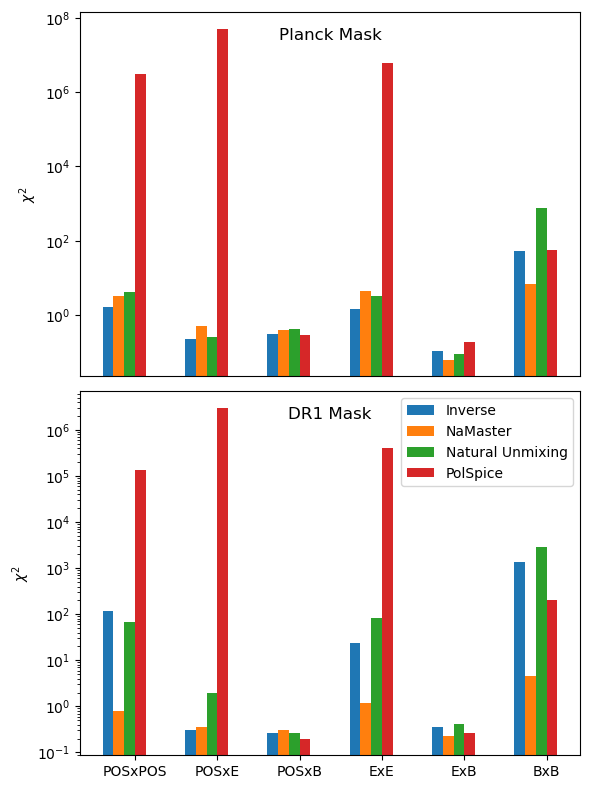

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(6, 8))
fig.subplots_adjust(hspace=0.0)

# List of chi-squared dictionaries to plot
chi2_dicts = {
    "Inverse": planck_xi2s_inv,
    "NaMaster": planck_xi2s_nmt,
    "Natural Unmixing": planck_xi2s_nu,
    "PolSpice": planck_xi2s_pols,
}
keys = list(chi2_dicts.values())[0].keys()
labels = [
    "POSxPOS", "POSxE", "POSxB",
    "ExE", "ExB", "BxB"
]

x = range(len(keys))
width = 0.13
for i, (name, d) in enumerate(chi2_dicts.items()):
    values = [d[k] for k in keys]
    axes[0].bar(
        [xi + i * width for xi in x],
        values,
        width=width,
        label=name
    )

axes[0].set_xticks([])
axes[0].set_xticklabels([])
axes[0].set_ylabel(r"$\chi^2$")
axes[0].set_title("Planck Mask", y=0.9)
axes[0].set_yscale("log")

# List of chi-squared dictionaries to plot
chi2_dicts = {
    "Inverse": dr1_xi2s_inv,
    "NaMaster": dr1_xi2s_nmt,
    "Natural Unmixing": dr1_xi2s_nu,
    "PolSpice": dr1_xi2s_pols,
}
keys = list(chi2_dicts.values())[0].keys()
labels = [
    "POSxPOS", "POSxE", "POSxB",
    "ExE", "ExB", "BxB"
]

x = range(len(keys))
width = 0.13
for i, (name, d) in enumerate(chi2_dicts.items()):
    values = [d[k] for k in keys]
    axes[1].bar(
        [xi + i * width for xi in x],
        values,
        width=width,
        label=name
    )

axes[1].set_xticks([xi + width*2.5 for xi in x])
axes[1].set_xticklabels(labels)
axes[1].set_ylabel(r"$\chi^2$")
axes[1].set_title("DR1 Mask", y=0.9)
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()
fig.savefig(f'/home/jaimerzp/Desktop/mixing_mat_plots/Xi2s_comp.pdf', bbox_inches='tight')

In [24]:
planck_xi2s_inv = get_xi2s(planck_inv_cqs_m, _theory_cqs, planck_ensemble_covqq)
planck_xi2s_nmt = get_xi2s(planck_nmt_cqs_m, _theory_cqs, planck_ensemble_covqq)
planck_xi2s_nu = get_xi2s(planck_nu_cqs_m, _theory_cqs, planck_ensemble_covqq)
planck_xi2s_pols = get_xi2s(planck_pols_cqs_m, _theory_cqs, planck_ensemble_covqq)

dr1_xi2s_inv = get_xi2s(dr1_inv_cqs_m, _theory_cqs, dr1_ensemble_covqq)
dr1_xi2s_nmt = get_xi2s(dr1_nmt_cqs_m, _theory_cqs, dr1_ensemble_covqq)
dr1_xi2s_nu = get_xi2s(dr1_nu_cqs_m, _theory_cqs, dr1_ensemble_covqq)
dr1_xi2s_pols = get_xi2s(dr1_pols_cqs_m, _theory_cqs, dr1_ensemble_covqq)

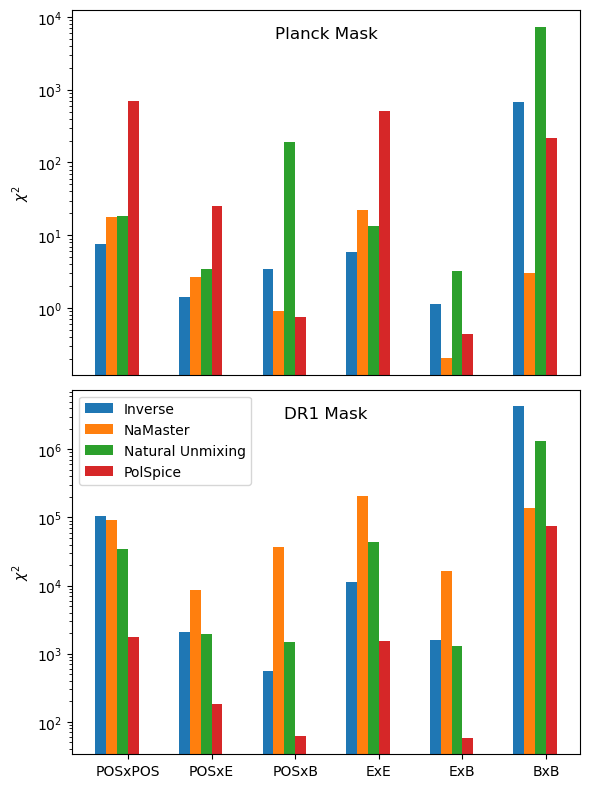

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(6, 8))
fig.subplots_adjust(hspace=0.0)

# List of chi-squared dictionaries to plot
chi2_dicts = {
    "Inverse": planck_xi2s_inv,
    "NaMaster": planck_xi2s_nmt,
    "Natural Unmixing": planck_xi2s_nu,
    "PolSpice": planck_xi2s_pols,
}
keys = list(chi2_dicts.values())[0].keys()
labels = [
    "POSxPOS", "POSxE", "POSxB",
    "ExE", "ExB", "BxB"
]

x = range(len(keys))
width = 0.13
for i, (name, d) in enumerate(chi2_dicts.items()):
    values = [d[k] for k in keys]
    axes[0].bar(
        [xi + i * width for xi in x],
        values,
        width=width,
        label=name
    )

axes[0].set_xticks([])
axes[0].set_xticklabels([])
axes[0].set_ylabel(r"$\chi^2$")
axes[0].set_title("Planck Mask", y=0.9)
axes[0].set_yscale("log")

# List of chi-squared dictionaries to plot
chi2_dicts = {
    "Inverse": dr1_xi2s_inv,
    "NaMaster": dr1_xi2s_nmt,
    "Natural Unmixing": dr1_xi2s_nu,
    "PolSpice": dr1_xi2s_pols,
}
keys = list(chi2_dicts.values())[0].keys()
labels = [
    "POSxPOS", "POSxE", "POSxB",
    "ExE", "ExB", "BxB"
]

x = range(len(keys))
width = 0.13
for i, (name, d) in enumerate(chi2_dicts.items()):
    values = [d[k] for k in keys]
    axes[1].bar(
        [xi + i * width for xi in x],
        values,
        width=width,
        label=name
    )

axes[1].set_xticks([xi + width*2.5 for xi in x])
axes[1].set_xticklabels(labels)
axes[1].set_ylabel(r"$\chi^2$")
axes[1].set_title("DR1 Mask", y=0.9)
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()
fig.savefig(f'/home/jaimerzp/Desktop/mixing_mat_plots/Xi2s_comp.pdf', bbox_inches='tight')